# EmotionCLIP-ReID RAF-DB Runbook

Notebook này dành riêng cho RAF-DB Basic. Protocol dùng official predefined split của RAF-DB: `train_*` để train và `test_*` để validation/test trong pipeline hiện tại. Không random split.

## 0. Kernel và repo

Chạy cell này trong đúng kernel/environment bạn muốn train.

In [2]:
from pathlib import Path
import os
import sys

REPO = Path.cwd()
if not (REPO / "train_emotionclip.py").exists():
    candidates = [Path("/mnt/e/Source/EmotionCLIP-ReID"), Path.home() / "EmotionCLIP-ReID"]
    for candidate in candidates:
        if (candidate / "train_emotionclip.py").exists():
            REPO = candidate
            os.chdir(REPO)
            break
print("Repo:", REPO)
print("Python:", sys.executable)

Repo: /home/jupyter-hault/EmotionCLIP-ReID
Python: /opt/tljh/user/envs/py310/bin/python


## 1. Kiểm tra package tối thiểu

In [3]:
import importlib.util
import subprocess
import sys

required = ["torch", "PIL", "yaml", "numpy","kaggle"]
missing = [name for name in required if importlib.util.find_spec(name) is None]
print("Missing:", missing)
if missing:
    print("Cài environment theo environment_emotionclip_cuda.yml hoặc cài các package còn thiếu trước khi train.")

# Kaggle chỉ cần nếu bạn muốn tải bằng Kaggle thay vì upload archive RAF-DB sẵn.
print("Kaggle module:", importlib.util.find_spec("kaggle") is not None)

Missing: []
Kaggle module: True


## 2. Process RAF-DB đã có sẵn

Notebook dùng trực tiếp thư mục `data/RAF-DB` hiện có. Cell này chỉ convert `train_labels.csv` và `test_labels.csv` sang `manifest.jsonl` theo predefined RAF-DB Basic protocol. Không tải dữ liệu và không random split.


In [5]:
!git pull


remote: Enumerating objects: 10, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 10 (delta 6), reused 10 (delta 6), pack-reused 0 (from 0)
Unpacking objects: 100% (10/10), 115.89 KiB | 562.00 KiB/s, done.
From https://github.com/haulth/EmotionCLIP-ReID
   b6abbbef..787c5cdd  main       -> origin/main
Updating b6abbbef..787c5cdd
Fast-forward
 data/RAF-DB/manifest.jsonl                         | 15339 +++++++++++++++++++
 .../emotionclip_reid_jupyterhub_fer2013.ipynb      |   177 +-
 notebooks/emotionclip_reid_jupyterhub_rafdb.ipynb  |   210 +-
 tools/convert_rafdb_to_emotion_jsonl.py            |    86 +-
 4 files changed, 15510 insertions(+), 302 deletions(-)
 create mode 100644 data/RAF-DB/manifest.jsonl


In [6]:
from pathlib import Path
import subprocess
import sys

RAF_ROOT = REPO / "data" / "RAF-DB"
RAF_MANIFEST = RAF_ROOT / "manifest.jsonl"

if not RAF_ROOT.exists():
    raise FileNotFoundError(f"Không thấy RAF-DB tại {RAF_ROOT}")
for required in ["train_labels.csv", "test_labels.csv"]:
    if not (RAF_ROOT / required).exists():
        raise FileNotFoundError(f"Thiếu {RAF_ROOT / required}")

convert_cmd = [
    sys.executable,
    "tools/convert_rafdb_to_emotion_jsonl.py",
    "--raf-root",
    str(RAF_ROOT),
    "--output",
    str(RAF_MANIFEST),
    "--root-dir",
    str(RAF_ROOT),
]
print("Converting existing data/RAF-DB -> EmotionCLIP manifest")
subprocess.run(convert_cmd, cwd=REPO, check=True)
print("RAF-DB manifest ready:", RAF_MANIFEST)


Converting existing data/RAF-DB -> EmotionCLIP manifest
Wrote 15339 RAF-DB records to /home/jupyter-hault/EmotionCLIP-ReID/data/RAF-DB/manifest.jsonl
Split protocol: RAF-DB official train/test split; no random split is created.
ROOT_DIR for training: /home/jupyter-hault/EmotionCLIP-ReID/data/RAF-DB
Label files: /home/jupyter-hault/EmotionCLIP-ReID/data/RAF-DB/train_labels.csv, /home/jupyter-hault/EmotionCLIP-ReID/data/RAF-DB/test_labels.csv
train: 12271
  anger: 705
  disgust: 717
  fear: 281
  happiness: 4772
  sadness: 1982
  surprise: 1290
  neutral: 2524
val: 3068
  anger: 162
  disgust: 160
  fear: 74
  happiness: 1185
  sadness: 478
  surprise: 329
  neutral: 680
RAF-DB manifest ready: /home/jupyter-hault/EmotionCLIP-ReID/data/RAF-DB/manifest.jsonl


## 3. Kiểm tra manifest và phân bố split

In [7]:
import json
from collections import Counter

assert RAF_MANIFEST.exists(), f"Missing manifest: {RAF_MANIFEST}"
records = [json.loads(line) for line in RAF_MANIFEST.read_text(encoding="utf-8").splitlines() if line.strip()]
print("Total records:", len(records))
print("Split counts:", Counter(record["split"] for record in records))
print("Official split counts:", Counter(record.get("official_split") for record in records))
print("Emotion counts:", Counter(record["emotion"] for record in records))
print("Split protocol:", records[0].get("split_protocol"))
records[:3]

Total records: 15339
Split counts: Counter({'train': 12271, 'val': 3068})
Official split counts: Counter({'train': 12271, 'test': 3068})
Emotion counts: Counter({'happiness': 5957, 'neutral': 3204, 'sadness': 2460, 'surprise': 1619, 'disgust': 877, 'anger': 867, 'fear': 355})
Split protocol: rafdb_official_train_test_no_random_split


[{'image_path': 'DATASET/train/5/train_00001_aligned.jpg',
  'emotion': 'sadness',
  'emotion_id': 4,
  'split': 'train',
  'source': 'RAF-DB',
  'split_protocol': 'rafdb_official_train_test_no_random_split',
  'rafdb_label_id': 5,
  'official_split': 'train',
  'official_image_name': 'train_00001_aligned.jpg'},
 {'image_path': 'DATASET/train/5/train_00002_aligned.jpg',
  'emotion': 'sadness',
  'emotion_id': 4,
  'split': 'train',
  'source': 'RAF-DB',
  'split_protocol': 'rafdb_official_train_test_no_random_split',
  'rafdb_label_id': 5,
  'official_split': 'train',
  'official_image_name': 'train_00002_aligned.jpg'},
 {'image_path': 'DATASET/train/4/train_00003_aligned.jpg',
  'emotion': 'happiness',
  'emotion_id': 3,
  'split': 'train',
  'source': 'RAF-DB',
  'split_protocol': 'rafdb_official_train_test_no_random_split',
  'rafdb_label_id': 4,
  'official_split': 'train',
  'official_image_name': 'train_00003_aligned.jpg'}]

## 4. Preview ảnh mẫu

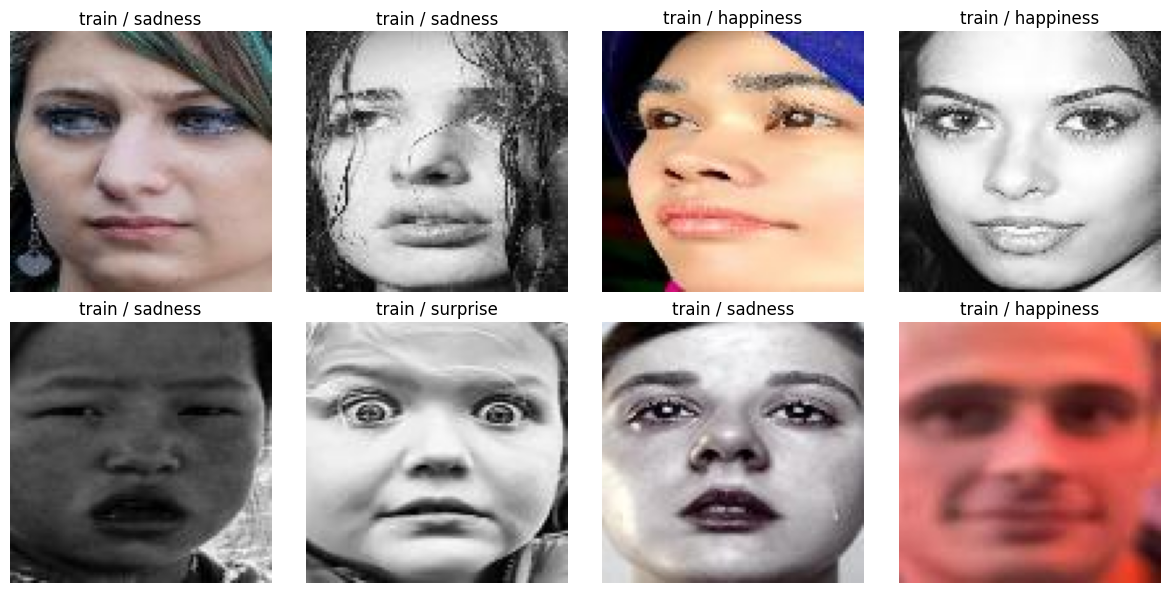

In [8]:
from PIL import Image
import matplotlib.pyplot as plt

sample_records = records[:8]
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, record in zip(axes.ravel(), sample_records):
    image_path = RAF_ROOT / record["image_path"]
    ax.imshow(Image.open(image_path).convert("RGB"))
    ax.set_title(f"{record['split']} / {record['emotion']}")
    ax.axis("off")
plt.tight_layout()

## 5. Train RAF-DB

In [ ]:
import subprocess
import sys

RAF_CONFIG = REPO / "configs" / "emotion" / "vit_b16_emotionclip_rafdb_quick.yml"
OUTPUT_DIR = REPO / "outputs" / "emotionclip_rafdb_quick"

train_cmd = [
    sys.executable,
    "train_emotionclip.py",
    "--config_file",
    str(RAF_CONFIG),
    "DATASETS.MANIFEST",
    str(RAF_MANIFEST),
    "DATASETS.ROOT_DIR",
    str(RAF_ROOT),
    "OUTPUT_DIR",
    str(OUTPUT_DIR),
]
subprocess.run(train_cmd, cwd=REPO, check=True)

2026-07-03 15:06:04,895 emotionclip.train INFO: Loaded config: {'MODEL': {'DEVICE': 'cuda', 'NAME': 'ViT-B-16', 'STRIDE_SIZE': [16, 16], 'EMOTION': {'N_CTX': 4, 'ADAPTER_DIM': 64, 'ADAPTER_DROPOUT': 0.0, 'TOPK_PATCHES': 5, 'GLOBAL_WEIGHT': 1.0, 'LOCAL_WEIGHT': 0.5, 'CLASSIFIER_WEIGHT': 1.0, 'TRAIN_LAST_BLOCKS': 1, 'STAGE1_WEIGHT': ''}}, 'INPUT': {'SIZE_TRAIN': [224, 224], 'SIZE_TEST': [224, 224], 'PROB': 0.5, 'COLOR_JITTER': 0.05, 'PIXEL_MEAN': [0.48145466, 0.4578275, 0.40821073], 'PIXEL_STD': [0.26862954, 0.26130258, 0.27577711]}, 'DATASETS': {'MANIFEST': '/home/jupyter-hault/EmotionCLIP-ReID/data/RAF-DB/manifest.jsonl', 'ROOT_DIR': '/home/jupyter-hault/EmotionCLIP-ReID/data/RAF-DB', 'STRICT_SPLIT_LEAKAGE': True}, 'DATALOADER': {'NUM_WORKERS': 0, 'PIN_MEMORY': False}, 'SOLVER': {'SEED': 1234, 'STAGE1': {'IMS_PER_BATCH': 64, 'MAX_EPOCHS': 2, 'BASE_LR': 0.00035, 'WEIGHT_DECAY': 0.0001, 'CHECKPOINT_PERIOD': 1, 'LOG_PERIOD': 20}, 'STAGE2': {'IMS_PER_BATCH': 32, 'MAX_EPOCHS': 3, 'BASE_LR':

## 6. Xem metrics tốt nhất hoặc epoch mới nhất

In [ ]:
import json
from pathlib import Path

metric_files = sorted(OUTPUT_DIR.glob("metrics_epoch_*.json"))
print("Metric files:", [path.name for path in metric_files[-5:]])
if metric_files:
    metrics = json.loads(metric_files[-1].read_text(encoding="utf-8"))
    for key in ["accuracy", "balanced_accuracy", "macro_f1", "avg_uncertainty", "avg_confidence", "ece", "uncertainty_risk_auc", "num_samples"]:
        print(key, metrics.get(key))
    print("Per-class F1:", metrics.get("per_class_f1"))

## 7. Infer một ảnh validation

In [ ]:
import subprocess
import sys

val_records = [record for record in records if record["split"] == "val"]
sample = val_records[0]
weight = OUTPUT_DIR / "best_emotionclip.pth"
image_path = RAF_ROOT / sample["image_path"]
print("Ground truth:", sample["emotion"])
print("Image:", image_path)
subprocess.run(
    [
        sys.executable,
        "infer_emotionclip.py",
        "--config_file",
        str(RAF_CONFIG),
        "--weight",
        str(weight),
        "--image",
        str(image_path),
    ],
    cwd=REPO,
    check=True,
)